# 14 — Index Extension: Folding AR/Reg30 Metrics into AINDEX, BINDEX, CINDEX

Extends 3 of the 6 governance sub-indices with 6 new metrics from `reg30_ar_metric_labels.csv`
that were confirmed as genuinely new (not already covered elsewhere in the CG index):

| Metric | Destination | Direction |
|---|---|---|
| `audit_fees_inr_crore` | AINDEX | ambiguous (kept as-is, not inverted — flagged) |
| `auditor_change_any` | AINDEX | negative (inverted) |
| `n_director_changes` | BINDEX | negative (inverted) |
| `n_rating_downgrades`* | CINDEX | negative (inverted) |
| `rpt_aggregate_inr_crore` | CINDEX | negative (inverted) |
| `promoter_pledge_pct` | CINDEX | negative (inverted) |

*Not `n_rating_changes` as originally labeled — that metric nets upgrades and downgrades
together (confirmed in `reg30_firm_fy_agg.py` L175-176: the exclusion list only drops
`reaffirmed/assigned/withdrawn/unclear`, never separates `upgrade` from `downgrade`), so a
firm with 3 upgrades and a firm with 3 downgrades would get an identical, meaningless
"higher = worse" score. Recomputed here from `reg30_events.csv` directly, split by
direction, keeping only genuine downgrades — the same crosswalk logic already validated
in `reg30_firm_fy_agg.py`, just not netted.

**Why CINDEX is the safe home for the low-coverage metrics (RPT 2.1%, pledge 4.0%)**:
CINDEX's aggregation (`06_index_calculation.ipynb`, cell 25) is a plain
`groupby(...)['Score'].mean()` — pandas skips NaN automatically, and CINDEX has no
"missing = governance failure = 0" convention (unlike AINDEX/BINDEX/DINDEX/OINDEX/TRINDEX,
where `missing_source` is explicitly scored 0 in the production `Avg_Score` column — the
actual mechanism behind DINDEX's Finding-1 variance collapse). A sparse new component here
just contributes NaN and gets excluded from that firm-quarter's mean — it is never dragged
toward a hard 0 the way DINDEX's D2-D5 failures were.

**Direction convention**: confirmed directly — CINDEX (like the rest of the framework) is
"higher = better governance." This could not be verified from any rubric/prompt file in
this repo (unlike D2-D5/A8, whose scoring prompt is in `cg_nlp_scorer.py`) — no file
documents how `cindex_scores.xlsx`'s C1-C10 components were originally scored, and C1-C3
average near 1 while C4-C10 average near 0, which is not obviously resolvable from the
data alone. Taken as a stated, not derived, fact for this notebook.

**Blending methodology**: for each destination index, a "new-metrics sub-score" is built
(mean of its assigned metrics' normalized 0-1 scores, skipping missing ones). The
augmented index score is the mean of `[original_index_score, new_sub_score]` — when the
sub-score is unavailable for a firm-FY, the augmented score equals the original,
unchanged (mean-of-available, not imputation). This applies equal weight to "everything
already in the index" vs. "everything new," rather than assigning arbitrary weights to
individual new metrics relative to the index's existing (and differently-weighted)
internal components.

**Nothing existing is modified.** `cg_scores.csv`, `09_regression.ipynb`, and every prior
notebook/output are untouched. This notebook reads already-saved files and writes exactly
one new file: `cg_scores_augmented_fy.csv`.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

BASE = Path.cwd()
PROC = BASE / 'data' / 'processed'
sys.path.insert(0, str(BASE))
import reg30_firm_fy_agg as r30agg  # reuse the validated direction crosswalk, don't reinvent

FYS = ['FY23', 'FY24', 'FY25']
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9,
                     'axes.spines.top': False, 'axes.spines.right': False})
print('Ready.')

Ready.


## 1 — Original FY-level CG scores

Same convention `09_regression.ipynb` already uses: quarterly `Avg_Score` averaged to
FY level per (BSE Code, FY, Category), then pivoted wide.

In [2]:
scores = pd.read_csv(PROC / 'cg_scores.csv')
scores['BSE Code'] = pd.to_numeric(scores['BSE Code'], errors='coerce')
scores['FY'] = 'FY' + scores['Q_FY'].str[-2:]

orig_fy = (scores[scores['FY'].isin(FYS)]
           .groupby(['BSE Code', 'FY', 'Category'])['Avg_Score'].mean()
           .reset_index()
           .pivot(index=['BSE Code', 'FY'], columns='Category', values='Avg_Score')
           .reset_index())
print(f'Original FY-level scores: {orig_fy.shape}')
print(orig_fy[['AINDEX', 'BINDEX', 'CINDEX']].describe().round(4))

Original FY-level scores: (741, 8)
Category   AINDEX   BINDEX   CINDEX
count    687.0000 687.0000 741.0000
mean       0.5849   0.6477   0.3698
std        0.0967   0.1337   0.0708
min        0.2936   0.2921   0.2247
25%        0.5214   0.5716   0.3130
50%        0.5888   0.6629   0.3504
75%        0.6568   0.7464   0.4220
max        0.8257   0.9488   0.6301


## 2 — New metrics: AR features + Reg30 director/auditor changes + recomputed rating downgrades

In [3]:
ar = pd.read_csv(PROC / 'ar_features_firm_fy.csv')
ar['BSE Code'] = pd.to_numeric(ar['BSE Code'], errors='coerce')
ar = ar[['BSE Code', 'FY', 'audit_fees_inr_crore', 'promoter_pledge_pct', 'rpt_aggregate_inr_crore']]
print(f'AR features: {len(ar)} rows')

reg30 = pd.read_csv(PROC / 'reg30_firm_fy.csv')
reg30['BSE Code'] = pd.to_numeric(reg30['BSE Code'], errors='coerce')
reg30 = reg30[['BSE Code', 'FY', 'n_director_changes', 'auditor_change_any', 'reg30_covered']]
print(f'Reg30 firm-FY: {len(reg30)} rows (100 firms x 3 FYs)')

# Rating downgrades ONLY -- recomputed from reg30_events.csv, not reg30_firm_fy.csv's
# n_rating_changes, to avoid the upgrade/downgrade netting issue.
ev = pd.read_csv(PROC / 'reg30_events.csv')
ev = ev[ev['_provenance'] == 'ok']
sample_ids = set(pd.read_csv(PROC / 'reg30_company_sample_100.csv')['BSE Code'])
ev = ev[ev['BSE Code'].isin(sample_ids)]  # exclude phantom companies, same as reg30_firm_fy_agg.py
ev['news_dt'] = pd.to_datetime(ev['news_dt'], format='mixed')
ev['Q_FY'] = ev['news_dt'].apply(r30agg._to_indian_fiscal_quarter)
ev['FY'] = 'FY' + ev['Q_FY'].str[-2:]

cr = ev[ev['event_class'] == 'credit_rating_change'].copy()
cr['direction_cw'] = cr['direction'].apply(r30agg.crosswalk_direction)
downgrades = cr[cr['direction_cw'] == 'downgrade']
n_downgrades = downgrades.groupby(['BSE Code', 'FY']).size().rename('n_rating_downgrades')
print(f'\nRating events: {len(cr)} total -> {len(downgrades)} genuine downgrades '
      f'(vs {(cr["direction_cw"]=="upgrade").sum()} upgrades, '
      f'{cr["direction_cw"].isin(r30agg.NON_CHANGE_DIRECTIONS).sum()} non-changes excluded)')

grid = pd.MultiIndex.from_product([sorted(sample_ids), FYS], names=['BSE Code', 'FY']).to_frame(index=False)
reg30_dg = grid.merge(n_downgrades, on=['BSE Code', 'FY'], how='left')
reg30_dg['n_rating_downgrades'] = reg30_dg['n_rating_downgrades'].fillna(0).astype(int)

AR features: 739 rows
Reg30 firm-FY: 300 rows (100 firms x 3 FYs)

Rating events: 531 total -> 29 genuine downgrades (vs 207 upgrades, 295 non-changes excluded)


## 3 — Normalize to 0-1, correct direction

Percentile rank within each FY cross-section (`.rank(pct=True)`) rather than min-max
scaling — robust to the extreme outliers already visible in the raw AR data (e.g.
`rpt_aggregate_inr_crore` has values into the millions of crore from unit-parsing edge
cases; a rank-based transform is unaffected by any single such outlier, unlike min-max).

`1 - rank` for every negative-direction metric so higher score = better governance,
matching the rest of the framework's convention. `audit_fees_inr_crore` is left
un-inverted (rank as-is) since its direction is genuinely ambiguous
(`reg30_ar_metric_labels.csv`) — flagging that choice rather than silently picking a
side.

In [4]:
panel = (orig_fy.merge(ar, on=['BSE Code', 'FY'], how='left')
                 .merge(reg30, on=['BSE Code', 'FY'], how='left')
                 .merge(reg30_dg, on=['BSE Code', 'FY'], how='left'))

def pct_rank(s):
    return s.groupby(panel['FY']).rank(pct=True)

panel['audit_fees_score']      = pct_rank(panel['audit_fees_inr_crore'])       # NOT inverted -- ambiguous direction
panel['auditor_change_score']  = 1 - panel['auditor_change_any']               # binary, already 0/1
panel['director_change_score'] = 1 - pct_rank(panel['n_director_changes'])
panel['rating_dg_score']       = 1 - pct_rank(panel['n_rating_downgrades'])
panel['rpt_score']             = 1 - pct_rank(panel['rpt_aggregate_inr_crore'])
panel['pledge_score']          = 1 - (panel['promoter_pledge_pct'] / 100)

print('Normalized component ranges (should all be within [0,1]):')
for c in ['audit_fees_score', 'auditor_change_score', 'director_change_score',
          'rating_dg_score', 'rpt_score', 'pledge_score']:
    print(f'  {c:24s} min={panel[c].min():.4f}  max={panel[c].max():.4f}  N={panel[c].notna().sum()}')

Normalized component ranges (should all be within [0,1]):
  audit_fees_score         min=0.0074  max=1.0000  N=393
  auditor_change_score     min=0.0000  max=1.0000  N=300
  director_change_score    min=0.0000  max=0.9000  N=300
  rating_dg_score          min=0.0000  max=0.5300  N=300
  rpt_score                min=0.0000  max=0.9091  N=21
  pledge_score             min=0.1900  max=1.0000  N=29


## 4 — Build sub-scores and blend into augmented indices

`X_new_sub` = mean of that index's assigned normalized metrics (skipping missing ones).
`X_augmented` = mean of `[X_original, X_new_sub]` -- equals `X_original` unchanged when
`X_new_sub` is unavailable for that firm-FY.

In [5]:
panel['AINDEX_new_sub'] = panel[['audit_fees_score', 'auditor_change_score']].mean(axis=1, skipna=True)
panel['BINDEX_new_sub'] = panel['director_change_score']
panel['CINDEX_new_sub'] = panel[['rating_dg_score', 'rpt_score', 'pledge_score']].mean(axis=1, skipna=True)

for idx in ['AINDEX', 'BINDEX', 'CINDEX']:
    panel[f'{idx}_augmented'] = panel[[idx, f'{idx}_new_sub']].mean(axis=1, skipna=True)

print('Coverage of new sub-scores (out of', len(panel), 'firm-FY rows):')
for col in ['AINDEX_new_sub', 'BINDEX_new_sub', 'CINDEX_new_sub']:
    print(f'  {col}: {panel[col].notna().sum()} ({panel[col].notna().mean():.1%})')
print('(BINDEX/CINDEX coverage is bounded by the 100-firm Reg30 stratified sample, not a')
print(' failure rate -- this is a sampling-scope limit, not missing data in the usual sense.)')

Coverage of new sub-scores (out of 741 firm-FY rows):
  AINDEX_new_sub: 531 (71.7%)
  BINDEX_new_sub: 300 (40.5%)
  CINDEX_new_sub: 325 (43.9%)
(BINDEX/CINDEX coverage is bounded by the 100-firm Reg30 stratified sample, not a
 failure rate -- this is a sampling-scope limit, not missing data in the usual sense.)


## 5 — Impact diagnostics: original vs augmented

Only computed over rows where the new sub-score was actually available (elsewhere the
two are identical by construction).

Impact (rows where the sub-score was available):
  AINDEX: 531 rows affected, mean delta=+0.0020, mean |delta|=0.1456, max |delta|=0.3803
  BINDEX: 300 rows affected, mean delta=-0.0751, mean |delta|=0.1484, max |delta|=0.4160
  CINDEX: 325 rows affected, mean delta=+0.0766, mean |delta|=0.1009, max |delta|=0.3625


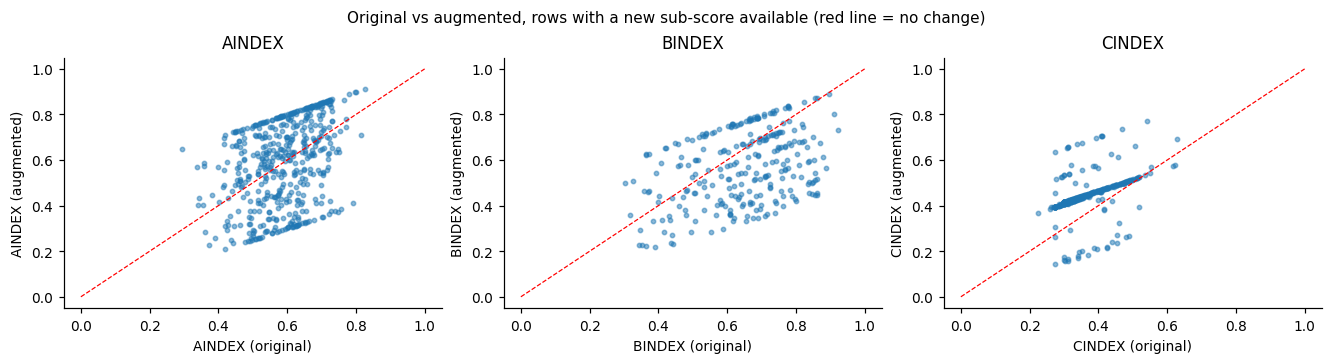

In [6]:
print('Impact (rows where the sub-score was available):')
for idx in ['AINDEX', 'BINDEX', 'CINDEX']:
    changed = panel[panel[f'{idx}_new_sub'].notna()]
    if len(changed):
        delta = (changed[f'{idx}_augmented'] - changed[idx])
        print(f'  {idx}: {len(changed)} rows affected, mean delta={delta.mean():+.4f}, '
              f'mean |delta|={delta.abs().mean():.4f}, max |delta|={delta.abs().max():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), constrained_layout=True)
for ax, idx in zip(axes, ['AINDEX', 'BINDEX', 'CINDEX']):
    changed = panel[panel[f'{idx}_new_sub'].notna()]
    ax.scatter(changed[idx], changed[f'{idx}_augmented'], s=8, alpha=0.5)
    ax.plot([0, 1], [0, 1], 'r--', lw=0.8)
    ax.set_xlabel(f'{idx} (original)'); ax.set_ylabel(f'{idx} (augmented)')
    ax.set_title(idx)
plt.suptitle('Original vs augmented, rows with a new sub-score available (red line = no change)', fontsize=10)
plt.show()

## 6 — Save

New file only -- `cg_scores.csv` and every existing notebook/output are untouched.

In [7]:
out_cols = ['BSE Code', 'FY',
            'AINDEX', 'AINDEX_new_sub', 'AINDEX_augmented',
            'BINDEX', 'BINDEX_new_sub', 'BINDEX_augmented',
            'CINDEX', 'CINDEX_new_sub', 'CINDEX_augmented',
            'DINDEX', 'OINDEX', 'TRINDEX']
panel[out_cols].to_csv(PROC / 'cg_scores_augmented_fy.csv', index=False)
print(f'Saved {len(panel)} rows -> data/processed/cg_scores_augmented_fy.csv')

print('\n' + '=' * 68)
print('  INDEX EXTENSION SUMMARY')
print('=' * 68)
print('AINDEX += audit_fees_inr_crore (ambiguous direction) + auditor_change_any (negative)')
print('BINDEX += n_director_changes (negative)')
print('CINDEX += n_rating_downgrades (negative, netting-fixed) + rpt_aggregate_inr_crore (negative)')
print('          + promoter_pledge_pct (negative)')
print()
print('Next step (not run here): re-run the primary-spec regression '
      '(09_regression.ipynb Section 10) substituting AINDEX_augmented/BINDEX_augmented/')
print('CINDEX_augmented for AINDEX/BINDEX/CINDEX, as a new, separately-labeled robustness')
print('table -- decided in advance, before looking at whether it changes the RW verdict.')
print('=' * 68)

Saved 741 rows -> data/processed/cg_scores_augmented_fy.csv

  INDEX EXTENSION SUMMARY
AINDEX += audit_fees_inr_crore (ambiguous direction) + auditor_change_any (negative)
BINDEX += n_director_changes (negative)
CINDEX += n_rating_downgrades (negative, netting-fixed) + rpt_aggregate_inr_crore (negative)
          + promoter_pledge_pct (negative)

Next step (not run here): re-run the primary-spec regression (09_regression.ipynb Section 10) substituting AINDEX_augmented/BINDEX_augmented/
CINDEX_augmented for AINDEX/BINDEX/CINDEX, as a new, separately-labeled robustness
table -- decided in advance, before looking at whether it changes the RW verdict.
